In [1]:
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
import statistics as sts 
import joblib
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error,mean_squared_error,median_absolute_error

In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\machineLearning1\predication01\Employee_Salary_Dataset.csv",encoding_errors='ignore')

In [3]:
df2=df1.copy()

In [4]:
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB


In [5]:
df2.sample(10)

,ID,Experience_Years,Age,Gender,Salary
34,35,16,49,Male,7600000
2,3,3,23,Female,170000
15,16,4,27,Female,87000
7,8,2,21,Female,9000
24,25,4,23,Female,8900
9,10,15,54,Female,650000
27,28,27,62,Female,10000000
31,32,15,54,Male,900000
20,21,15,54,Male,6570000
4,5,1,17,Male,10000


In [6]:
mapping={
    'Male':1,
    'Female':2
}
df2['Gender_encoded']=df2['Gender'].map(mapping)


In [9]:
df2.drop(columns=['Gender'],inplace=True)

In [11]:
df2.drop(columns=['ID'],inplace=True)

In [15]:
list(df2.columns)

['Experience_Years', 'Age', 'Salary', 'Gender_encoded']

In [16]:
df2.rename(columns={'Experience_Years':"EXP", 'Age':"AGE", 'Salary':"SAL", 'Gender_encoded':"GENE"},inplace=True)

In [18]:
df2.sample(10)

,EXP,AGE,SAL,GENE
7,2,21,9000,2
6,19,54,800000,2
16,10,34,930000,2
13,11,40,220100,1
30,10,34,80000,1
9,15,54,650000,2
0,5,28,250000,2
29,2,21,6100,2
2,3,23,170000,2
20,15,54,6570000,1


In [19]:
df2.drop_duplicates(inplace=True)

In [21]:
df2.dropna(axis=0,how='any',inplace=True)

In [22]:
df2

,EXP,AGE,SAL,GENE
0,5,28,250000,2
1,1,21,50000,1
2,3,23,170000,2
3,2,22,25000,1
4,1,17,10000,1
5,25,62,5001000,1
6,19,54,800000,2
7,2,21,9000,2
8,10,36,61500,2
9,15,54,650000,2


In [23]:
df2.columns

Index(['EXP', 'AGE', 'SAL', 'GENE'], dtype='object')

In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   EXP     35 non-null     int64
 1   AGE     35 non-null     int64
 2   SAL     35 non-null     int64
 3   GENE    35 non-null     int64
dtypes: int64(4)
memory usage: 1.2 KB


In [25]:
x=df2[['EXP','AGE','GENE']]
y=df2['SAL']

In [ ]:
import statistics as sts 

class Anomolies_detction:
    def __init__(self,data):
        self.data=data      
    def main_fuunction(self):
        anomolies=[]
        mean_value=sts.mean(self.data)
        std_value=sts.stdev(self.data)
        cutoff=3*std_value
        left_bound=mean_value-cutoff
        right_bound=mean_value+cutoff
        for each_point in self.data:
            if each_point < left_bound or each_point > right_bound:
                anomolies.append(each_point)
        return anomolies
    
anomiles_instance=Anomolies_detction(df2['SAL'])
result_anomolies=anomiles_instance.main_fuunction()
print(result_anomolies)

[]


In [31]:
df2.columns

Index(['EXP', 'AGE', 'SAL', 'GENE'], dtype='object')

In [64]:
from numpy import astype
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)
linear_reg_salary_predication=LinearRegression()

model_pipeline=Pipeline(steps=(
    'linear_model',linear_reg_salary_predication  
)
)
linear_reg_salary_predication.fit(x_train,y_train)
y_salary=linear_reg_salary_predication.predict(x_test)
print(y_salary)

print(r2_score(y_test,y_salary))
print(mean_absolute_error(y_test,y_salary))
print(mean_squared_error(y_test,y_salary))
print(root_mean_squared_error(y_test,y_salary))
print(round(df2.corr(method='pearson'),3))
print(linear_reg_salary_predication.score(x_test,y_salary))

[ 171764.02934588 3122348.93580803  261201.46371402 1066592.63495862]
-293.07597644574923
1091226.7659566368
2400025357198.0474
1549201.5224618285
        EXP    AGE    SAL   GENE
EXP   1.000  0.974  0.686  0.126
AGE   0.974  1.000  0.668  0.116
SAL   0.686  0.668  1.000 -0.001
GENE  0.126  0.116 -0.001  1.000
1.0


In [47]:
print(round(df2.corr(method='spearman'),3))

        EXP    AGE    SAL   GENE
EXP   1.000  0.979  0.856  0.145
AGE   0.979  1.000  0.844  0.105
SAL   0.856  0.844  1.000  0.023
GENE  0.145  0.105  0.023  1.000


<Figure size 1000x700 with 0 Axes>

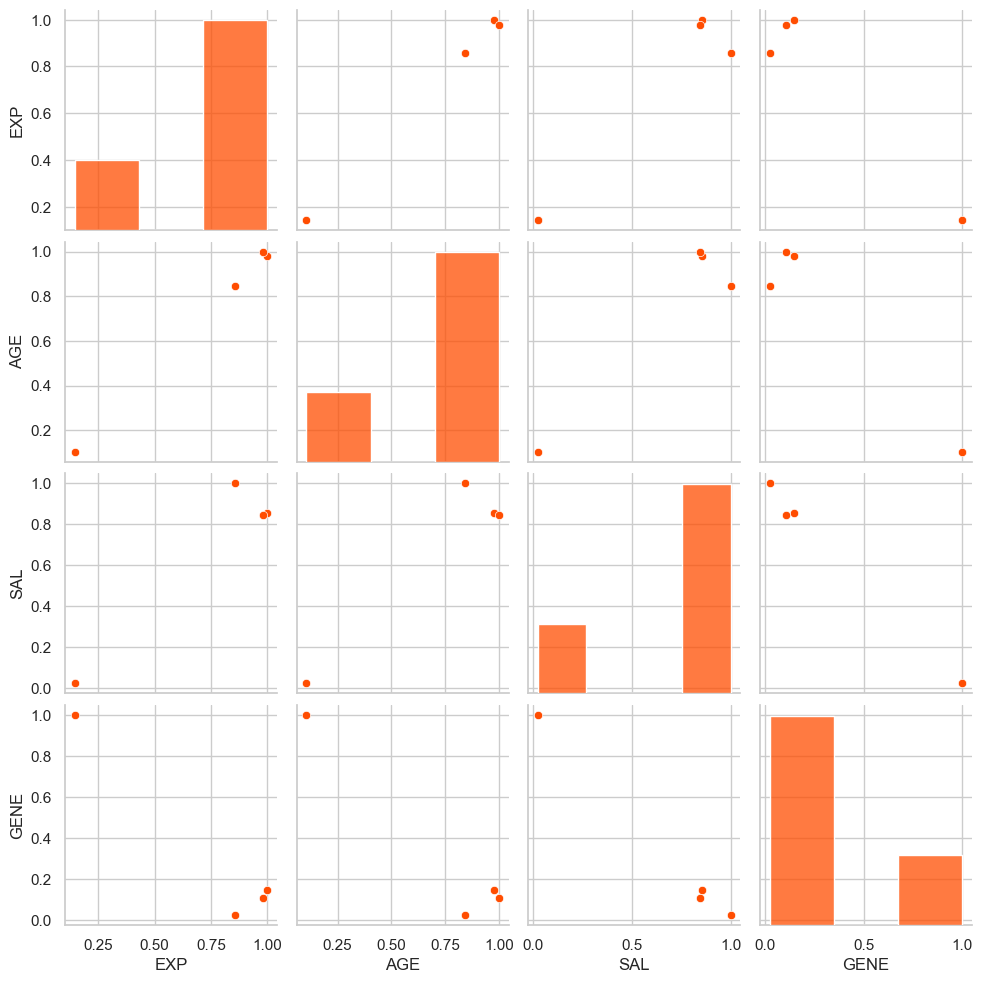

In [54]:
from matplotlib.pyplot import tight_layout


drawing=round(df2.corr(method='spearman'),3)

col1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,7))
sns.set_theme(style='whitegrid',palette=col1)
sns.pairplot(drawing)
plt.show()

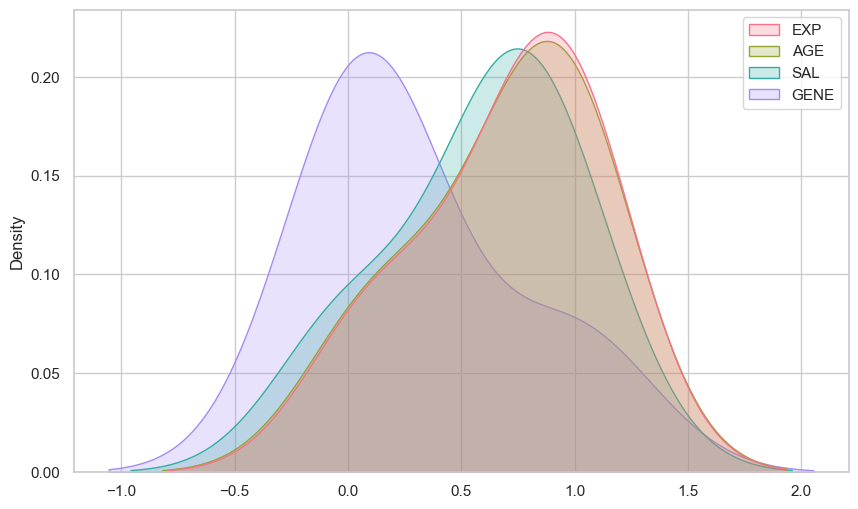

In [61]:
drawing=round(df2.corr(method='pearson'),3)

col1=['#ff4d01','#ffffff']
plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid',palette=col1)
sns.kdeplot(drawing,fill=True)
plt.show()

In [60]:
joblib.dump(linear_reg_salary_predication,'linear_reg_salary.joblib')

['linear_reg_salary.joblib']

In [63]:
df2.describe()

,EXP,AGE,SAL,GENE
count,35.00000,35.000000,3.500000e+01,35.000000
mean,9.20000,35.485714,2.059147e+06,1.514286
std,7.55295,14.643552,3.170124e+06,0.507093
min,1.00000,17.000000,3.000000e+03,1.000000
25%,2.50000,22.500000,2.250000e+04,1.000000
50%,6.00000,29.000000,2.500000e+05,2.000000
75%,15.00000,53.500000,3.270000e+06,2.000000
max,27.00000,62.000000,1.000000e+07,2.000000


In [ ]:
import streamlit as st
import joblib
import pandas as pd

try:
    salary_model = joblib.load(
        r"C:\Shravan\PythonPratice\supervised\machineLearning1\predication01\linear_reg_salary.joblib"
    )
    st.write("model is loaded successfully")
    st.title("EMP SALARY PREDICATIONS")
    st.balloons()
    with st.sidebar.form(key="form values"):
        with st.sidebar:
            st.header("Enter the Input values")
            EXP = st.number_input("EXP", min_value=1, max_value=28, value=2)
            AGE = st.number_input("AGE", min_value=17, max_value=65, value=20)
            GENE = st.number_input(
                "GENE",
                min_value=1,
                max_value=2,
                value=2,
                help="1 is male and 2 is for female",
            )
            submit_buttom = st.form_submit_button(label="submit")
            # success_msg = st.success(submit_buttom)
            # st.write(success_msg)
    data1 = {"EXP": EXP, "AGE": AGE, "GENE": GENE}
    dataframe1 = pd.DataFrame(data=data1, index=[0])
    predications = salary_model.predict(dataframe1)

    st.write(f" salary is : INR : {predications[0]:,.3f}")
except Exception as e:
    error = st.error(f"{str(e)} error message")
    st.code(f"{str(e)}", language="python")
    st.info(error)
else:
    print("no errors in the code ....!")
finally:
    print("final block is excuted")


2025-12-23 12:08:41.268 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:08:41.464 
  command:

    streamlit run C:\Users\PesalaShravanKumar\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-23 12:08:41.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:08:41.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:08:41.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:08:41.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:08:41.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-23 12:0

In [95]:
from datetime import datetime,time,date

current_datetime=datetime.now()
current_date=date.today()
print(current_datetime)

2025-12-23 13:42:18.415660
